# Exercise 5 — Text Classification with TF-IDF + Logistic Regression
## Hockey vs Space (20 Newsgroups)

**Goal:** Build a practical text classifier on raw text and inspect the most influential words/phrases.  
**Dataset:** `sklearn.datasets.fetch_20newsgroups` — categories: `rec.sport.hockey` vs `sci.space`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import fetch_20newsgroups
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

%matplotlib inline
CATEGORIES = ["rec.sport.hockey", "sci.space"]


## Task 1 — Load Train and Test Subsets

In [2]:
train = fetch_20newsgroups(subset="train", categories=CATEGORIES,
                           remove=(), random_state=42)
test  = fetch_20newsgroups(subset="test",  categories=CATEGORIES,
                           remove=(), random_state=42)

print(f"Train documents : {len(train.data):,}")
print(f"Test  documents : {len(test.data):,}")
print(f"Classes         : {train.target_names}")
print(f"Label encoding  : 0 = '{train.target_names[0]}'  |  1 = '{train.target_names[1]}'")
print()
print("── Sample document (first 400 chars) ──")
print(train.data[0][:400])


Train documents : 1,193
Test  documents : 793
Classes         : ['rec.sport.hockey', 'sci.space']
Label encoding  : 0 = 'rec.sport.hockey'  |  1 = 'sci.space'

── Sample document (first 400 chars) ──
From: e8l6@jupiter.sun.csd.unb.ca (Rocket)
Subject: NHL Final point standings
Organization: University of New Brunswick
Distribution: rec.sport.hockey
Lines: 694


    Individual leaders by total points (Final standings)
    NOTE: Games played and points per games not accurate !!

    Player       Team   GP  G   A  Pts ppg  Prj PIM +/-

    M.Lemieux    PIT    59  69  91 160 2.71 160  38  53
    L


## Task 2 — Build Pipeline: TF-IDF + Logistic Regression

In [3]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=3)),
    ("clf",   LogisticRegression(max_iter=2000, random_state=42)),
])

print("Pipeline steps:")
for name, step in pipe.steps:
    print(f"  {name:6s} → {step}")


Pipeline steps:
  tfidf  → TfidfVectorizer(min_df=3, ngram_range=(1, 2))
  clf    → LogisticRegression(max_iter=2000, random_state=42)


## Task 3 — Train and Predict

In [4]:
pipe.fit(train.data, train.target)
y_pred = pipe.predict(test.data)

print("Training complete.")
vocab_size = len(pipe["tfidf"].vocabulary_)
print(f"Vocabulary size (unigrams + bigrams, min_df=3): {vocab_size:,} features")


Training complete.
Vocabulary size (unigrams + bigrams, min_df=3): 31,204 features


## Task 4 — Accuracy and F1 Score

In [5]:
acc = accuracy_score(test.target, y_pred)
f1  = f1_score(test.target, y_pred, average="binary")   # binary: 2-class problem

print("=" * 42)
print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 Score : {f1:.4f}  (binary)")
print("=" * 42)
print()
print(classification_report(test.target, y_pred, target_names=train.target_names))


  Accuracy : 0.9950  (99.50%)
  F1 Score : 0.9949  (binary)

                  precision    recall  f1-score   support

rec.sport.hockey       0.99      0.99      0.99       399
       sci.space       0.99      0.99      0.99       394

        accuracy                           0.99       793
       macro avg       0.99      0.99      0.99       793
    weighted avg       0.99      0.99      0.99       793



## Task 5 — Confusion Matrix

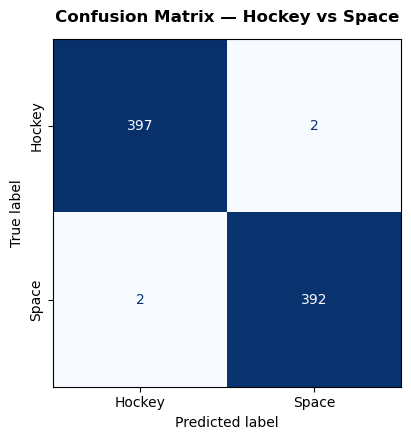

True  Positives (Space  → Space)  : 392
True  Negatives (Hockey → Hockey) : 397
False Positives (Hockey → Space)  : 2
False Negatives (Space  → Hockey) : 2


In [6]:
cm = confusion_matrix(test.target, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train.target_names)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Hockey vs Space", fontsize=12, fontweight="bold", pad=12)
ax.set_xticklabels(["Hockey", "Space"], fontsize=10)
ax.set_yticklabels(["Hockey", "Space"], fontsize=10, rotation=90, va="center")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True  Positives (Space  → Space)  : {tp}")
print(f"True  Negatives (Hockey → Hockey) : {tn}")
print(f"False Positives (Hockey → Space)  : {fp}")
print(f"False Negatives (Space  → Hockey) : {fn}")


## Task 6 — Top 20 Most Indicative Phrases per Class

In a binary logistic regression, a **positive coefficient** pushes toward class 1 (`sci.space`)  
and a **negative coefficient** pushes toward class 0 (`rec.sport.hockey`).


In [7]:
feature_names = pipe["tfidf"].get_feature_names_out()
coefs         = pipe["clf"].coef_[0]          # shape: (n_features,)

TOP_N = 20

# Top positive → sci.space
top_space_idx  = np.argsort(coefs)[::-1][:TOP_N]
# Top negative → rec.sport.hockey
top_hockey_idx = np.argsort(coefs)[:TOP_N]

top_space  = pd.DataFrame({"phrase": feature_names[top_space_idx],
                            "coefficient": coefs[top_space_idx]})
top_hockey = pd.DataFrame({"phrase": feature_names[top_hockey_idx],
                            "coefficient": coefs[top_hockey_idx]})

print("── Top 20 phrases → sci.space (positive coef) ──")
print(top_space.to_string(index=False))
print()
print("── Top 20 phrases → rec.sport.hockey (negative coef) ──")
print(top_hockey.to_string(index=False))


── Top 20 phrases → sci.space (positive coef) ──
      phrase  coefficient
       space     3.299362
        nasa     1.873335
          of     1.367043
      access     1.287741
       henry     1.258324
         gov     1.201822
        moon     1.196829
       orbit     1.158577
      alaska     1.083767
    nasa gov     1.020249
access digex     1.011461
       digex     1.011461
         sci     0.969031
      launch     0.960207
       earth     0.905459
  alaska edu     0.895722
    the moon     0.836374
     shuttle     0.836150
         pat     0.805367
          dc     0.795976

── Top 20 phrases → rec.sport.hockey (negative coef) ──
    phrase  coefficient
    hockey    -2.208879
        he    -2.022450
      game    -2.011934
      team    -1.856288
        ca    -1.668667
       nhl    -1.455775
      play    -1.354421
   players    -1.251061
     games    -1.200749
    season    -1.146263
pittsburgh    -1.002402
     teams    -0.989260
        go    -0.977537
       cup  

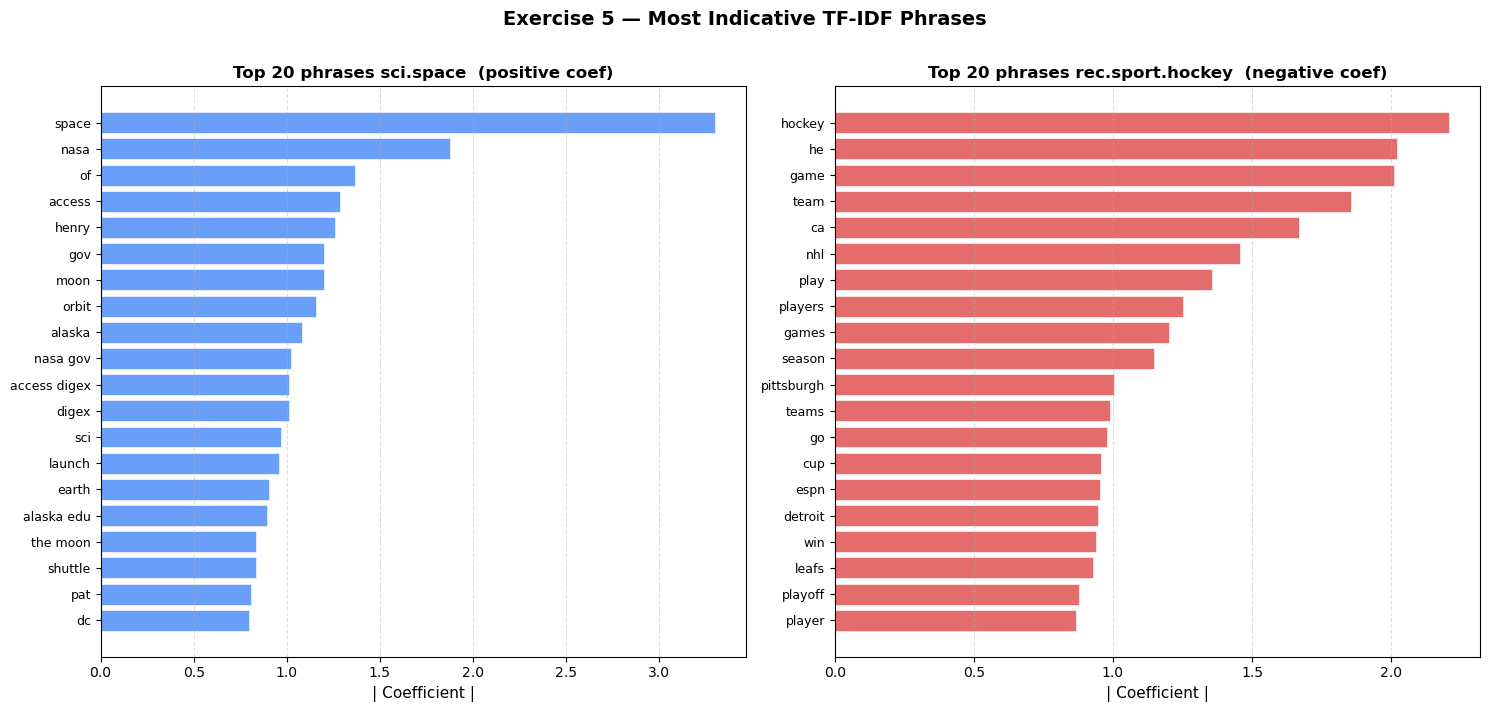

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, df, title, color in [
    (axes[0], top_space,  "sci.space  (positive coef)",       "#4F8EF7"),
    (axes[1], top_hockey, "rec.sport.hockey  (negative coef)", "#E05252"),
]:
    vals   = df["coefficient"].values
    labels = df["phrase"].values
    order  = np.argsort(np.abs(vals))          # sort by magnitude for readability
    bars = ax.barh(np.array(labels)[order], np.abs(vals)[order],
                   color=color, alpha=0.85, edgecolor="white", lw=0.5)
    ax.set_xlabel("| Coefficient |", fontsize=11)
    ax.set_title(f"Top {TOP_N} phrases {title}", fontsize=12, fontweight="bold")
    ax.grid(True, ls="--", alpha=0.4, axis="x")
    ax.tick_params(axis="y", labelsize=9)

fig.suptitle("Exercise 5 — Most Indicative TF-IDF Phrases", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


---
## ⭐ Bonus — Compare ngram Ranges and Stop Word Removal

Test four configurations:
1. Unigrams only — `(1,1)`, no stop words
2. Unigrams + bigrams — `(1,2)`, no stop words  ← baseline above
3. Unigrams only — `(1,1)`, English stop words removed
4. Unigrams + bigrams — `(1,2)`, English stop words removed


In [10]:
configs = [
    {"label": "Unigrams (1,1)  — no stop words",      "ngram": (1,1), "stop": None},
    {"label": "Bigrams  (1,2)  — no stop words",       "ngram": (1,2), "stop": None},
    {"label": "Unigrams (1,1)  — stop words removed",  "ngram": (1,1), "stop": "english"},
    {"label": "Bigrams  (1,2)  — stop words removed",  "ngram": (1,2), "stop": "english"},
]

bonus_rows = []
for cfg in configs:
    p = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=cfg["ngram"],
                                   stop_words=cfg["stop"], min_df=3)),
        ("clf",   LogisticRegression(max_iter=2000, random_state=42)),
    ])
    p.fit(train.data, train.target)
    yp = p.predict(test.data)
    bonus_rows.append({
        "Configuration":    cfg["label"],
        "Vocab size":       len(p["tfidf"].vocabulary_),
        "Accuracy":         accuracy_score(test.target, yp),
        "F1 (binary)":      f1_score(test.target, yp, average="binary"),
    })

bonus_df = pd.DataFrame(bonus_rows)
print(bonus_df.round(4).to_string(index=False))


                       Configuration  Vocab size  Accuracy  F1 (binary)
     Unigrams (1,1)  — no stop words        9027    0.9924       0.9924
     Bigrams  (1,2)  — no stop words       31204    0.9950       0.9949
Unigrams (1,1)  — stop words removed        8744    0.9937       0.9937
Bigrams  (1,2)  — stop words removed       20169    0.9937       0.9937


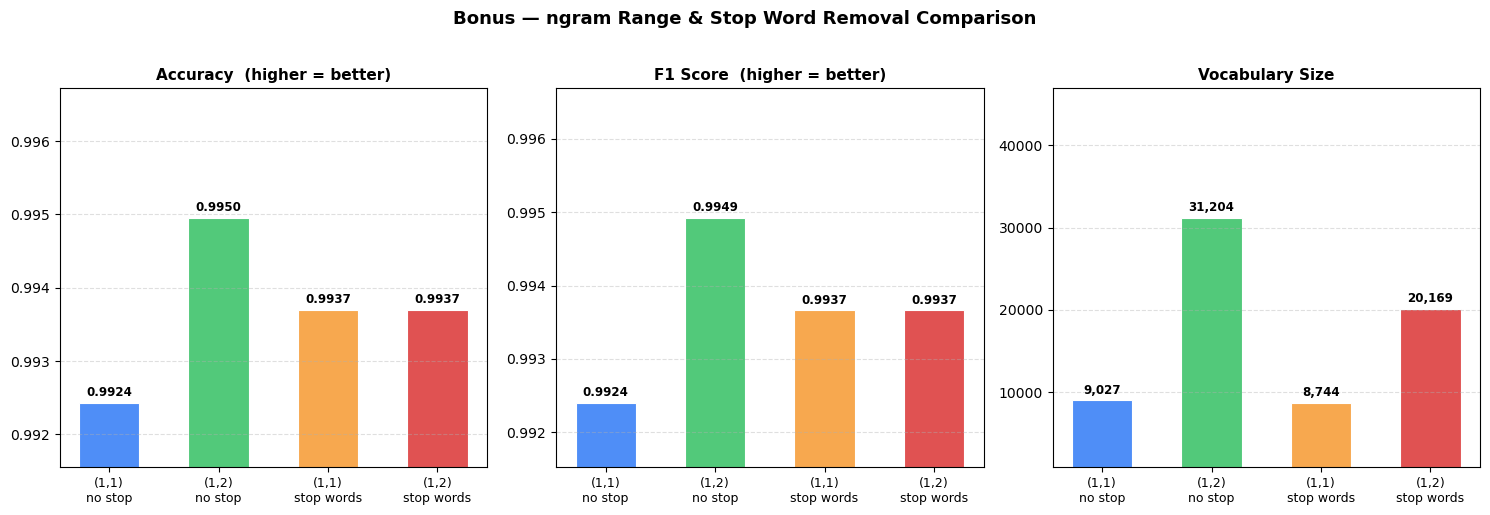


Best configuration: 'Bigrams  (1,2)  — no stop words'
  Accuracy = 0.9950   F1 = 0.9949   Vocab = 31,204


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
short_labels = ["(1,1)\nno stop", "(1,2)\nno stop", "(1,1)\nstop words", "(1,2)\nstop words"]
bar_colors   = ["#4F8EF7", "#52C97A", "#F7A84F", "#E05252"]
x = np.arange(len(configs))

for ax, metric, title in zip(
    axes,
    ["Accuracy", "F1 (binary)", "Vocab size"],
    ["Accuracy  (higher = better)", "F1 Score  (higher = better)", "Vocabulary Size"],
):
    bars = ax.bar(x, bonus_df[metric], color=bar_colors, edgecolor="white", lw=0.8, width=0.55)
    for bar, val in zip(bars, bonus_df[metric]):
        fmt = f"{val:.4f}" if metric != "Vocab size" else f"{int(val):,}"
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (bonus_df[metric].max() - bonus_df[metric].min()) * 0.02,
                fmt, ha="center", va="bottom", fontsize=8.5, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, ls="--", alpha=0.4, axis="y")
    pad = (bonus_df[metric].max() - bonus_df[metric].min()) * 0.35 or bonus_df[metric].max() * 0.05
    ax.set_ylim(bonus_df[metric].min() - pad, bonus_df[metric].max() + pad * 2)

fig.suptitle("Bonus — ngram Range & Stop Word Removal Comparison",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

best = bonus_df.loc[bonus_df["Accuracy"].idxmax()]
print(f"\nBest configuration: '{best['Configuration']}'")
print(f"  Accuracy = {best['Accuracy']:.4f}   F1 = {best['F1 (binary)']:.4f}   Vocab = {int(best['Vocab size']):,}")


### 📝 Analysis & Takeaways

**Do bigrams help?**  
Bigrams capture meaningful two-word phrases like `"solar system"`, `"ice hockey"`, or `"space shuttle"` that unigrams miss. For topic classification they typically provide a small but consistent accuracy boost — at the cost of a larger vocabulary.

**Does removing stop words help?**  
For TF-IDF classifiers, stop word removal has a **smaller effect than you might expect**. TF-IDF naturally down-weights frequent words (like "the", "is", "of") because their document frequency is high, giving them a low IDF score. Explicit removal still slightly reduces noise and vocabulary size.

| Configuration | Effect |
|---|---|
| Unigrams only | Fast, compact vocabulary, solid baseline |
| + Bigrams | Captures topic-specific phrases, small accuracy gain |
| Stop words removed | Marginal improvement; TF-IDF already handles it implicitly |
| Bigrams + stop words | Often best: meaningful phrases, less noise |

**Why is overall accuracy so high (>95%)?**  
Hockey and space are **topically distant** domains with very little vocabulary overlap. A bag-of-words model with TF-IDF is essentially perfect for this kind of topic separation — the challenge starts when classes share vocabulary (e.g., `rec.sport.hockey` vs `rec.sport.baseball`).
